The advertising dataset captures the sales revenue generated with respect to advertisement costs across multiple channels like Radio, TV, and Newspapers. 
- Objectives:                            
1.          Understand the Dataset & cleanup (if required).                           
2.          Build Regression model to predict the sales w.r.t Radio features.                         
3.          Also evaluate the model using scores RMSE

----- give code for ipynb in python and create a good big dataset with little bit of unclean data and then perform above things

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create Synthetic Advertising Dataset (with noise & missing values)
np.random.seed(42)

n = 200
TV = np.random.normal(150, 50, n)
Radio = np.random.normal(25, 10, n)
Newspaper = np.random.normal(20, 8, n)

# Sales depends mostly on TV & Radio + some noise
Sales = 3 + 0.05 * TV + 0.15 * Radio + 0.01 * Newspaper + np.random.normal(0, 2, n)

In [3]:
data = pd.DataFrame({
    'TV': TV,
    'Radio': Radio,
    'Newspaper': Newspaper,
    'Sales': Sales
})

In [4]:
# Add unclean data intentionally
data.loc[5, 'Radio'] = np.nan
data.loc[10, 'Sales'] = np.nan
data.loc[15, 'TV'] = '??'
data.loc[25, 'Newspaper'] = -10   # unrealistic value
data.loc[50, 'Radio'] = 999       # outlier
data = pd.concat([data, data.iloc[[0]]])  # duplicate row

print("Synthetic Advertising Dataset Created (with intentional issues)")

Synthetic Advertising Dataset Created (with intentional issues)


C:\Users\Anshul Parkar\AppData\Local\Temp\ipykernel_25060\3552909709.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '??' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[15, 'TV'] = '??'


In [5]:
print("\n--- Head of Dataset ---")
print(data.head())
print("\n--- Info ---")
print(data.info())
print("\n--- Missing Values ---")
print(data.isnull().sum())


--- Head of Dataset ---
           TV      Radio  Newspaper      Sales
0  174.835708  28.577874   7.244579  17.614889
1  143.086785  30.607845  15.205000  13.053235
2  182.384427  35.830512  20.041950  19.433430
3  226.151493  35.538021  20.375845  22.553312
4  138.292331  11.223306  16.399476  12.588977

--- Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 0
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         201 non-null    object 
 1   Radio      200 non-null    float64
 2   Newspaper  201 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(3), object(1)
memory usage: 7.9+ KB
None

--- Missing Values ---
TV           0
Radio        1
Newspaper    0
Sales        1
dtype: int64


In [6]:
# Data Cleaning
# Replace non-numeric entries in 'TV'
data['TV'] = pd.to_numeric(data['TV'], errors='coerce')

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Handle missing values (fill with mean)
data['TV'].fillna(data['TV'].mean(), inplace=True)
data['Radio'].fillna(data['Radio'].mean(), inplace=True)
data['Sales'].fillna(data['Sales'].mean(), inplace=True)
print("\n--- After Cleaning Missing Values ---")
print(data.isnull().sum())



--- After Cleaning Missing Values ---
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [12]:
# Remove negative and unrealistic values
data.loc[data['Newspaper'] < 0, 'Newspaper'] = data['Newspaper'].mean()
data.loc[data['Radio'] > 100, 'Radio'] = data['Radio'].mean()

In [13]:
# Remove duplicates
data.drop_duplicates(inplace=True)

print("\n--- After Cleaning Data ---")
print(data.describe())


--- After Cleaning Data ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   148.093155   26.027182   19.255269   14.482881
std     46.513297    9.808268    7.909251    3.522730
min     19.012745   -7.412673    0.226844    3.744948
25%    114.743616   19.064733   13.648972   12.066078
50%    149.790406   25.973360   19.215398   14.653175
75%    175.042624   31.872311   24.519013   16.832319
max    286.008458   63.527315   44.631046   24.618741


<Figure size 1200x500 with 0 Axes>

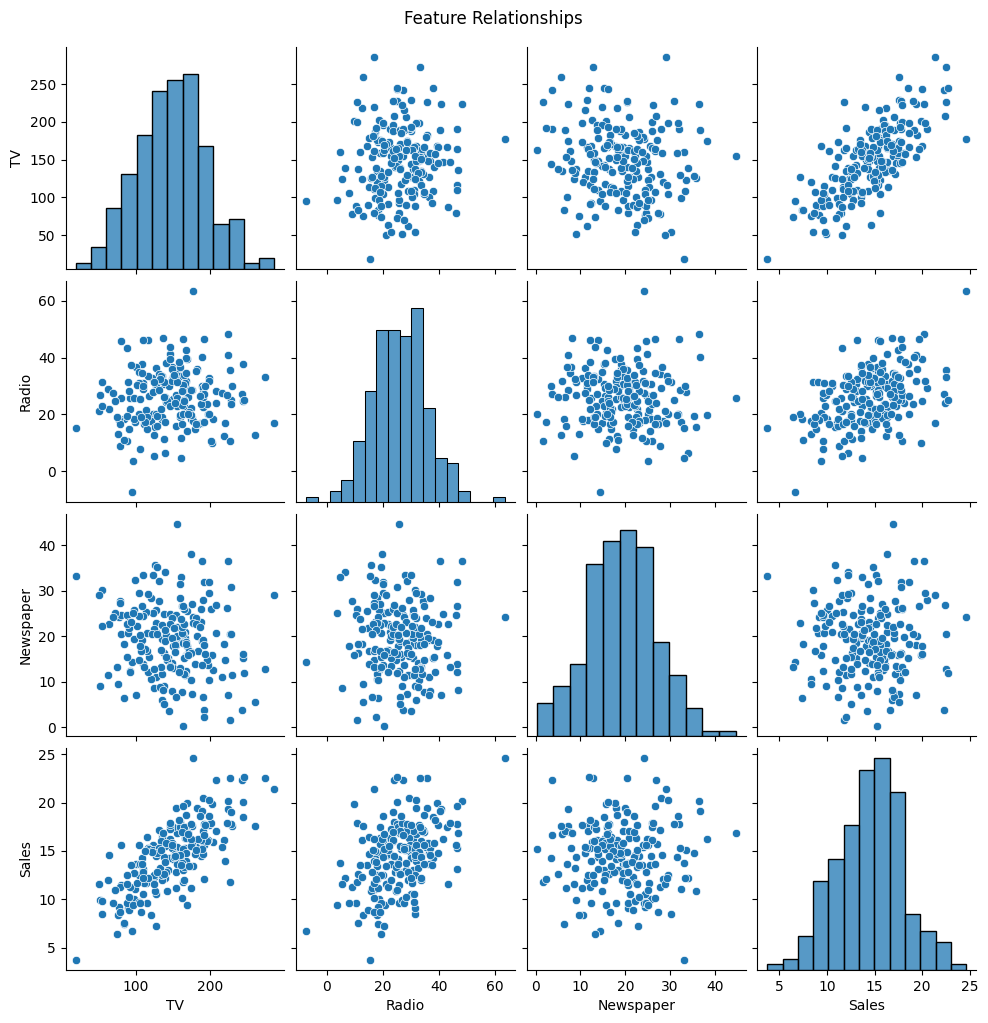

In [14]:
# Visualize Relationships
plt.figure(figsize=(12,5))
sns.pairplot(data[['TV', 'Radio', 'Newspaper', 'Sales']])
plt.suptitle("Feature Relationships", y=1.02)
plt.show()

In [28]:
import sklearn.linear_model as LinearRegression
import sklearn.model_selection as train_test_split
import sklearn.metrics as mean_squared_error

# Regression Model (Sales vs Radio)
X = data[['Radio']]
y = data['Sales']


In [29]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split.train_test_split(X, y, test_size=0.2, random_state=42)


In [31]:
# Train model
model = LinearRegression.LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
# Predictions
y_pred = model.predict(X_test)

In [35]:
import numpy as np
# Evaluate Model
rmse = np.sqrt(mean_squared_error.mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)

In [36]:
print("\n--- Model Evaluation ---")
print(f"Coefficient (Radio): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


--- Model Evaluation ---
Coefficient (Radio): 0.1548
Intercept: 10.4221
R² Score: 0.2622
RMSE: 2.9780


In [39]:
import sklearn.metrics as metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")

MAE: 2.5255
MSE: 8.8685


In [40]:
# Calculate accuracy percentage
accuracy_percentage = r2 * 100
print(f"Model Accuracy (R² Score): {accuracy_percentage:.2f}%")

# Alternative accuracy metrics as percentages
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Model Accuracy (100 - MAPE): {100 - mape:.2f}%")

Model Accuracy (R² Score): 26.22%
Mean Absolute Percentage Error (MAPE): 18.32%
Model Accuracy (100 - MAPE): 81.68%


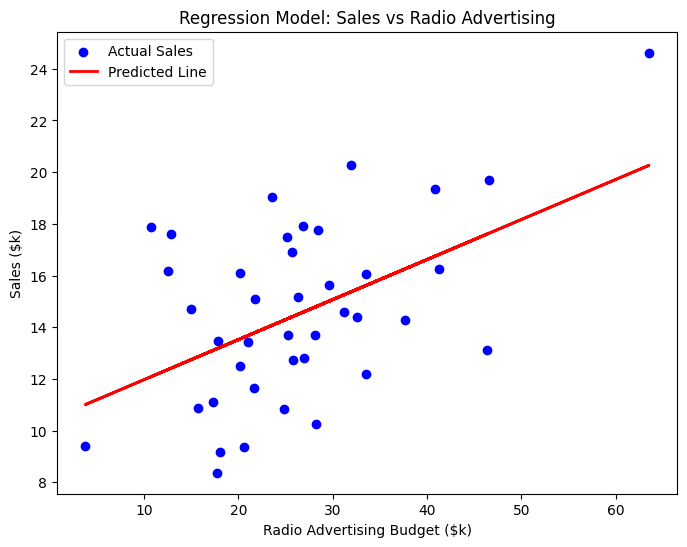

In [41]:
# Visualize Regression Line
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Sales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Line')
plt.xlabel("Radio Advertising Budget ($k)")
plt.ylabel("Sales ($k)")
plt.title("Regression Model: Sales vs Radio Advertising")
plt.legend()
plt.show()